In [1]:
   !pip install mlflow xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 88.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 12.4 MB/s eta 0:00:00


In [2]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [8]:
df = pd.read_csv('/kaggle/input/datasets/ahadahmad01/emi-prediction-dataset/emi_prediction_dataset.csv', low_memory=False)

In [9]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [10]:
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

Rows: 404,800, Columns: 27


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [12]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

education         2404
monthly_rent      2426
credit_score      2420
bank_balance      2426
emergency_fund    2351
dtype: int64

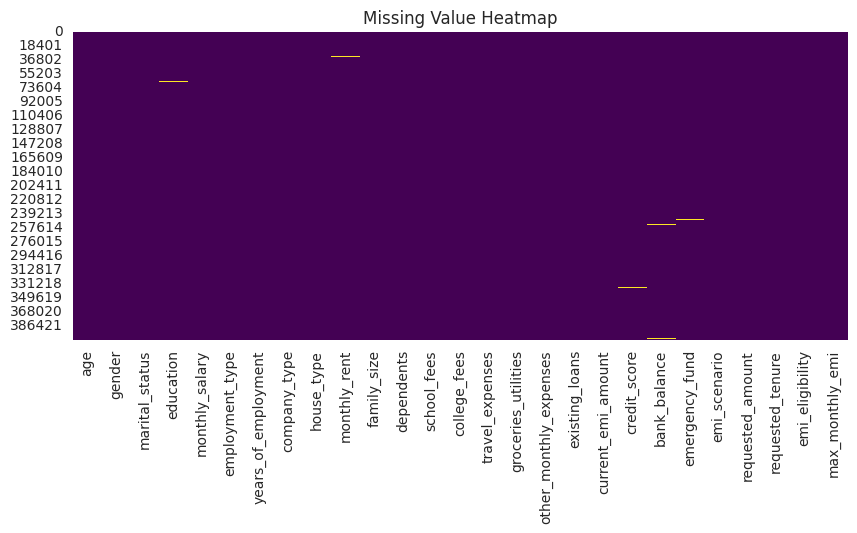

In [14]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [15]:
df.columns.tolist()

['age',
 'gender',
 'marital_status',
 'education',
 'monthly_salary',
 'employment_type',
 'years_of_employment',
 'company_type',
 'house_type',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'existing_loans',
 'current_emi_amount',
 'credit_score',
 'bank_balance',
 'emergency_fund',
 'emi_scenario',
 'requested_amount',
 'requested_tenure',
 'emi_eligibility',
 'max_monthly_emi']

In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,404800,31,38,119883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,404800,8,Male,237427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,404800,2,Married,307837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,402396,4,Graduate,181015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_salary,404800,13662,18000.0,4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,404800,3,Private,283099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_employment,404800.0,NaN,NaN,NaN,5.364079,6.079135,0.5,1.2,3.2,7.2,36.0
company_type,404800,5,Large Indian,121139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_type,404800,3,Rented,161601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_rent,402374.0,NaN,NaN,NaN,5828.44649,8648.604639,0.0,0.0,0.0,10600.0,80000.0


In [17]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:10]}")

age: 31 unique -> ['38' '58' '48' '32' '27' '47' '58.0' '37' '32.0' '27.0']
gender: 8 unique -> ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
marital_status: 2 unique -> ['Married' 'Single']
education: 4 unique -> ['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
monthly_salary: 13662 unique -> ['82600.0' '21500.0' '86100.0' '66800.0' '57300.0' '38800.0' '27100.0'
 '392044.0' '47700.0' '129200.0']
employment_type: 3 unique -> ['Private' 'Government' 'Self-employed']
company_type: 5 unique -> ['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']
house_type: 3 unique -> ['Rented' 'Family' 'Own']
existing_loans: 2 unique -> ['Yes' 'No']
bank_balance: 12261 unique -> ['303200.0' '92500.0' '672100.0' '440900.0' '97300.0' '260800.0' '68000.0'
 '184600.0' '235600.0' '963200.0']
emi_scenario: 5 unique -> ['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']
emi_eligibility: 3 unique -> ['Not_Eligible' 'Eligible' 'High_Risk']


In [18]:
def clean_corrupted_numeric(series):
    def _clean(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip()
        if s.lower() == 'nan':
            return np.nan
        s = re.sub(r'(\.0)+$', '', s)  # strip repeated trailing ".0" occurrences
        try:
            return float(s)
        except ValueError:
            return np.nan
    return series.apply(_clean)

for col in ['age', 'monthly_salary', 'bank_balance']:
    df[col] = clean_corrupted_numeric(df[col])

print(df[['age', 'monthly_salary', 'bank_balance']].describe())

                 age  monthly_salary  bank_balance
count  404800.000000   404800.000000  4.023600e+05
mean       38.875860    59501.887530  2.416890e+05
std         9.303593    43367.251049  1.832267e+05
min        26.000000     3967.000000  6.100000e+03
25%        32.000000    35400.000000  1.044000e+05
50%        38.000000    51700.000000  1.960000e+05
75%        48.000000    73000.000000  3.312000e+05
max        59.000000   499970.000000  1.717300e+06


In [19]:
gender_map = {
    'Female': 'Female', 'female': 'Female', 'F': 'Female', 'FEMALE': 'Female',
    'Male': 'Male', 'male': 'Male', 'M': 'Male', 'MALE': 'Male',
}
df['gender'] = df['gender'].map(gender_map)
print(df['gender'].value_counts())

gender
Male      242950
Female    161850
Name: count, dtype: int64


In [20]:
before_out_of_range = ((df['credit_score'] < 300) | (df['credit_score'] > 850)).sum()
df['credit_score'] = df['credit_score'].clip(lower=300, upper=850)
print(f"Out-of-range credit_score values clipped: {before_out_of_range}")

Out-of-range credit_score values clipped: 4776


In [21]:
df['education'] = df['education'].fillna(df['education'].mode()[0])

# monthly_rent: missing likely means no rent obligation (e.g. living with family) -> fill 0
df['monthly_rent'] = df['monthly_rent'].fillna(0)

# credit_score: fill with median (robust to the extreme values we just clipped)
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())

# bank_balance, emergency_fund: fill with median (financial values, right-skewed)
df['bank_balance'] = df['bank_balance'].fillna(df['bank_balance'].median())
df['emergency_fund'] = df['emergency_fund'].fillna(df['emergency_fund'].median())

print(df.isnull().sum()[df.isnull().sum() > 0])
print("All nulls resolved" if df.isnull().sum().sum() == 0 else "Nulls remain -- check above")

Series([], dtype: int64)
All nulls resolved


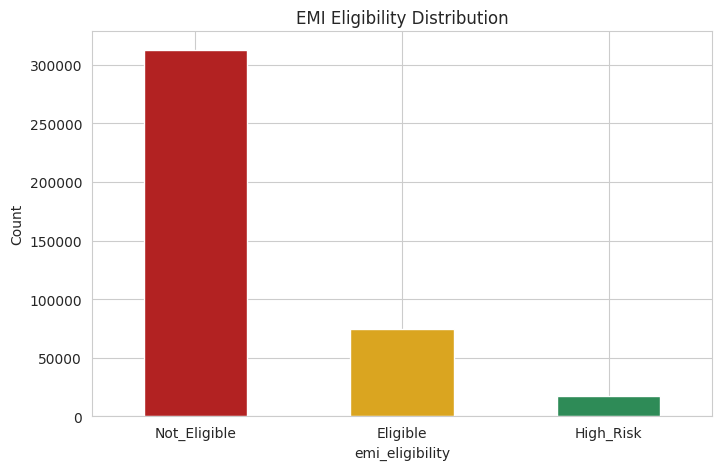

In [22]:
plt.figure(figsize=(8,5))
df['emi_eligibility'].value_counts().plot(kind='bar', color=['firebrick','goldenrod','seagreen'])
plt.title('EMI Eligibility Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

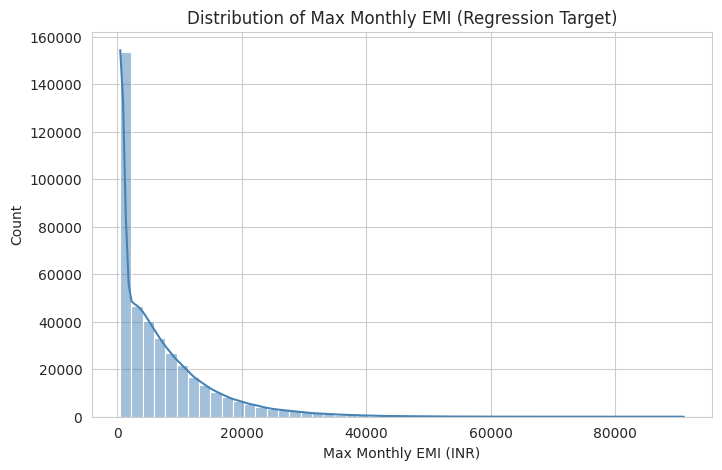

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['max_monthly_emi'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Max Monthly EMI (Regression Target)')
plt.xlabel('Max Monthly EMI (INR)')
plt.show()

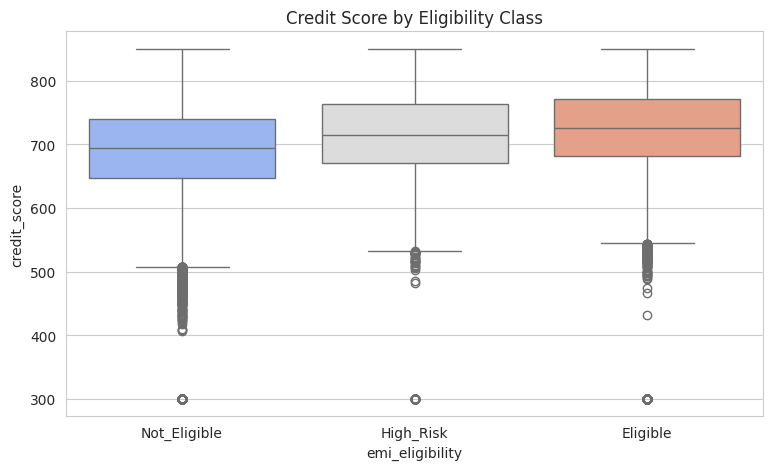

In [24]:
plt.figure(figsize=(9,5))
sns.boxplot(x='emi_eligibility', y='credit_score', data=df, order=['Not_Eligible','High_Risk','Eligible'], palette='coolwarm')
plt.title('Credit Score by Eligibility Class')
plt.show()

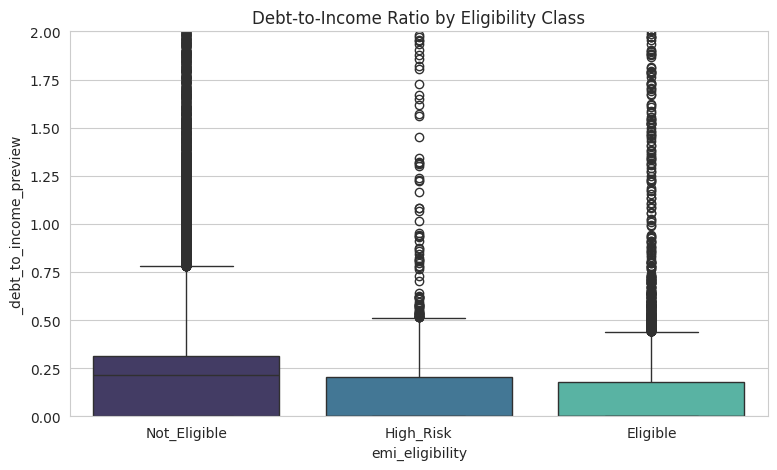

In [25]:
df['_debt_to_income_preview'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary'].replace(0, np.nan)
plt.figure(figsize=(9,5))
sns.boxplot(x='emi_eligibility', y='_debt_to_income_preview', data=df, order=['Not_Eligible','High_Risk','Eligible'], palette='mako')
plt.title('Debt-to-Income Ratio by Eligibility Class')
plt.ylim(0, 2)
plt.show()
df.drop(columns=['_debt_to_income_preview'], inplace=True)

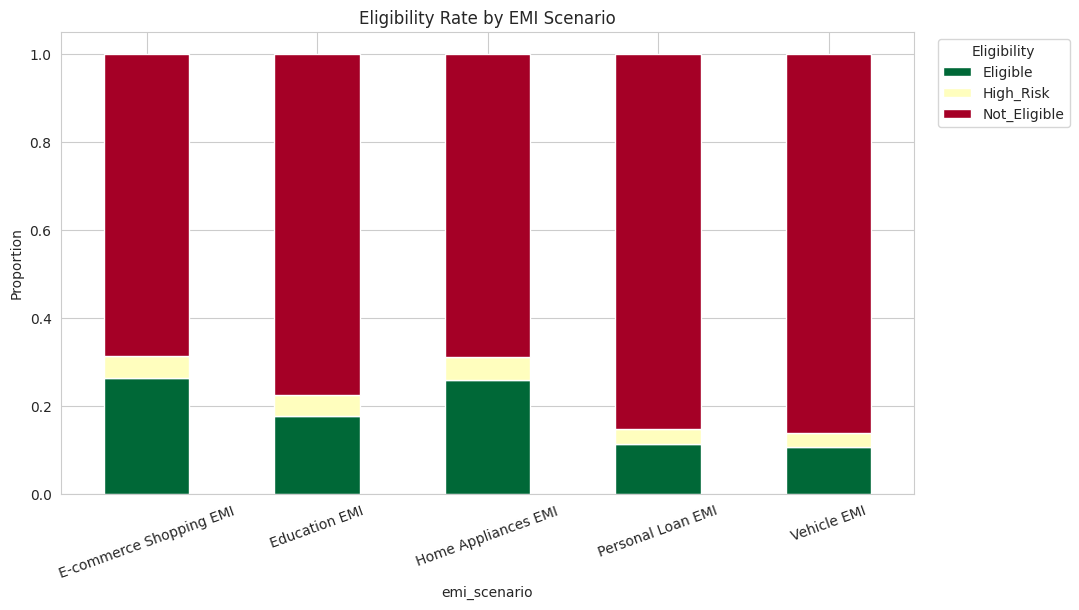

In [26]:
pd.crosstab(df['emi_scenario'], df['emi_eligibility'], normalize='index').plot(kind='bar', stacked=True, figsize=(11,6), colormap='RdYlGn_r')
plt.title('Eligibility Rate by EMI Scenario')
plt.ylabel('Proportion')
plt.xticks(rotation=20)
plt.legend(title='Eligibility', bbox_to_anchor=(1.02,1))
plt.show()

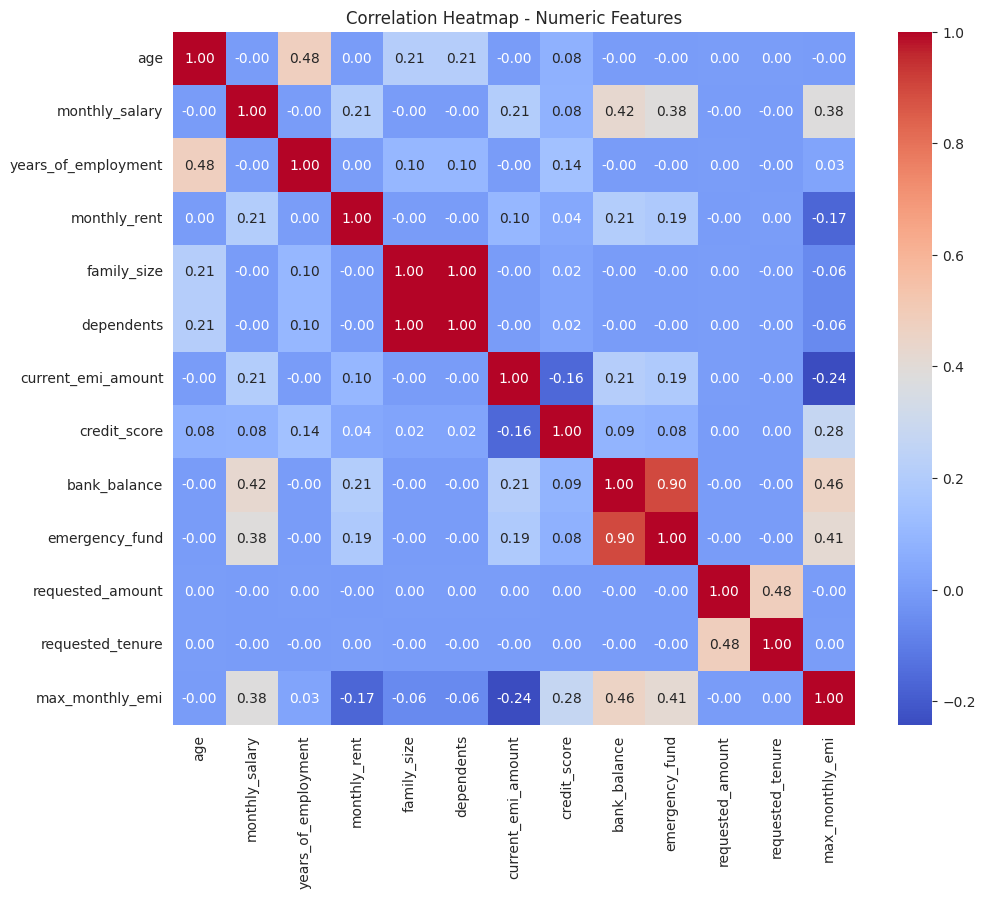

In [27]:
numeric_cols = ['age','monthly_salary','years_of_employment','monthly_rent','family_size','dependents',
                 'current_emi_amount','credit_score','bank_balance','emergency_fund','requested_amount',
                 'requested_tenure','max_monthly_emi']
plt.figure(figsize=(11,9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

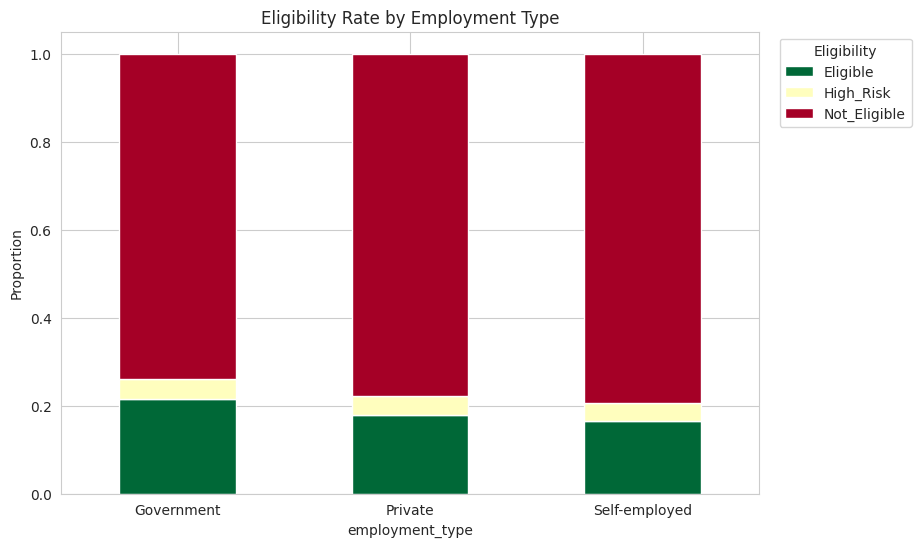

In [28]:
pd.crosstab(df['employment_type'], df['emi_eligibility'], normalize='index').plot(kind='bar', stacked=True, figsize=(9,6), colormap='RdYlGn_r')
plt.title('Eligibility Rate by Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Eligibility', bbox_to_anchor=(1.02,1))
plt.show()

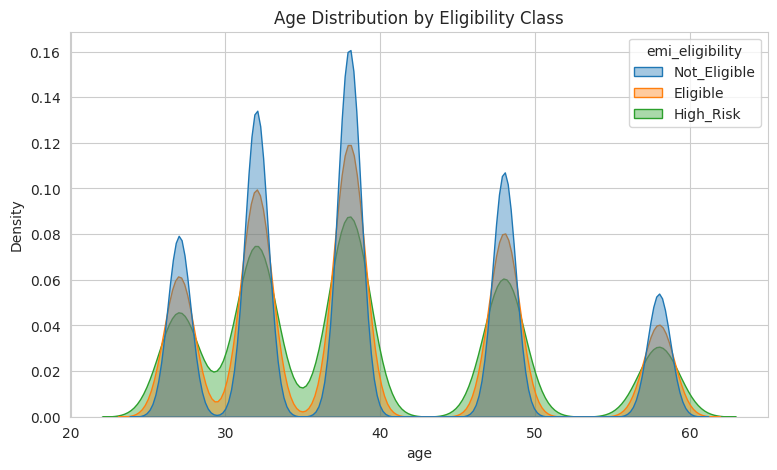

In [29]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=df, x='age', hue='emi_eligibility', fill=True, common_norm=False, alpha=0.4)
plt.title('Age Distribution by Eligibility Class')
plt.show()

In [30]:
from scipy import stats

groups = [df[df['emi_eligibility']==c]['credit_score'].dropna() for c in ['Not_Eligible','High_Risk','Eligible']]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, P-value: {p_val:.5f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0")

F-statistic: 6198.708, P-value: 0.00000
Reject H0


In [31]:
df['_dti_check'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary'].replace(0, np.nan)
elig = df[df['emi_eligibility']=='Eligible']['_dti_check'].dropna()
not_elig = df[df['emi_eligibility']=='Not_Eligible']['_dti_check'].dropna()

t_stat, p_val = stats.ttest_ind(elig, not_elig, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.5f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0")
df.drop(columns=['_dti_check'], inplace=True)

T-statistic: -166.697, P-value: 0.00000
Reject H0


In [32]:
contingency = pd.crosstab(df['employment_type'], df['emi_eligibility'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2: {chi2:.3f}, P-value: {p_val:.5f}, dof: {dof}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0")

Chi2: 707.252, P-value: 0.00000, dof: 4
Reject H0


In [33]:
# Total monthly expenses (all obligation columns combined)
df['total_monthly_expenses'] = (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] + df['travel_expenses'] +
    df['groceries_utilities'] + df['other_monthly_expenses'] + df['current_emi_amount']
)

# Debt-to-income ratio: current EMI + rent burden relative to income
df['debt_to_income'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary'].replace(0, np.nan)

# Expense-to-income ratio: all monthly obligations relative to income
df['expense_to_income'] = df['total_monthly_expenses'] / df['monthly_salary'].replace(0, np.nan)

# Affordability ratio: how much of the requested amount the applicant could plausibly cover per month
# relative to income, given the requested tenure
df['affordability_ratio'] = (df['requested_amount'] / df['requested_tenure'].replace(0, np.nan)) / df['monthly_salary'].replace(0, np.nan)

# Disposable income: salary minus total expenses
df['disposable_income'] = df['monthly_salary'] - df['total_monthly_expenses']

# Simple composite risk score: normalized credit_score + employment stability - dependents burden
df['risk_score'] = (
    (df['credit_score'] / 850) * 0.5 +
    (df['years_of_employment'].clip(upper=15) / 15) * 0.3 -
    (df['dependents'].clip(upper=5) / 5) * 0.2
)

# Clean up any inf/-inf from divisions by (near) zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)
engineered_cols = ['total_monthly_expenses','debt_to_income','expense_to_income','affordability_ratio','disposable_income','risk_score']
df[engineered_cols] = df[engineered_cols].fillna(df[engineered_cols].median())

df[engineered_cols].describe()

,total_monthly_expenses,debt_to_income,expense_to_income,affordability_ratio,disposable_income,risk_score
count,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000
mean,44639.560099,0.191259,0.867220,0.346611,14862.327431,0.431104
std,23072.348857,0.245442,0.636739,0.460533,37607.924371,0.110393
min,3600.000000,0.000000,0.011144,0.001005,-161883.000000,0.026471
25%,27900.000000,0.000000,0.607057,0.099899,400.000000,0.352000
50%,40600.000000,0.183946,0.779130,0.206484,10600.000000,0.412471
75%,56700.000000,0.288591,0.990854,0.415735,22400.000000,0.496588
max,247800.000000,16.297906,31.291979,17.613636,485540.000000,0.800000


In [34]:
categorical_cols = ['gender','marital_status','education','employment_type','company_type',
                    'house_type','existing_loans','emi_scenario']

# One-hot encode all categorical columns (none are ordinal in a way that would justify label/ordinal encoding)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (404800, 43)


In [35]:
numeric_features = ['age','monthly_salary','years_of_employment','monthly_rent','family_size','dependents',
                    'school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses',
                    'current_emi_amount','credit_score','bank_balance','emergency_fund','requested_amount',
                    'requested_tenure','total_monthly_expenses','debt_to_income','expense_to_income',
                    'affordability_ratio','disposable_income','risk_score']

scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])
df_encoded[numeric_features].describe().T[['mean','std']]

,mean,std
age,-1.592051e-17,1.000001
monthly_salary,-5.939913e-17,1.000001
years_of_employment,-3.240271e-16,1.000001
monthly_rent,3.240271e-17,1.000001
family_size,1.081919e-16,1.000001
dependents,-8.210823e-17,1.000001
school_fees,9.834908e-17,1.000001
college_fees,-7.876879e-17,1.000001
travel_expenses,-3.050700e-17,1.000001
groceries_utilities,-5.360666e-17,1.000001


In [36]:
feature_cols = [c for c in df_encoded.columns if c not in ['emi_eligibility', 'max_monthly_emi']]

X = df_encoded[feature_cols]
y_clf = df_encoded['emi_eligibility']
y_reg = df_encoded['max_monthly_emi']

# Classification split (stratified, to preserve the imbalanced class ratio in both sets)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Regression split (same feature matrix, different target, same random_state for a consistent split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Classification -> Train: {X_train_clf.shape[0]:,}, Test: {X_test_clf.shape[0]:,}")
print(f"Regression -> Train: {X_train_reg.shape[0]:,}, Test: {X_test_reg.shape[0]:,}")


Classification -> Train: 323,840, Test: 80,960
Regression -> Train: 323,840, Test: 80,960


In [37]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_clf)
weights = compute_class_weight('balanced', classes=classes, y=y_train_clf)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {'Eligible': np.float64(1.812554221587888), 'High_Risk': np.float64(7.715436113692135), 'Not_Eligible': np.float64(0.43127948199583954)}


In [38]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')

mlflow.set_experiment('EMIPredict_Classification')

2026/08/23 11:41:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/23 11:41:46 INFO mlflow.store.db.utils: Updating database tables
2026/08/23 11:41:48 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_Classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='/kaggle/working/mlruns/1', creation_time=1787485308662, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787485308662, lifecycle_stage='active', name='EMIPredict_Classification', tags={}, trace_location=None, workspace='default'>

In [40]:
def evaluate_classifier(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    try:
        auc = roc_auc_score(pd.get_dummies(y_true), y_proba, average='weighted', multi_class='ovr')
    except Exception:
        auc = np.nan
    print(f"{name} -> Accuracy: {acc:.4f}, Weighted F1: {f1:.4f}, Macro F1: {macro_f1:.4f}, ROC-AUC: {auc:.4f}")
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'Weighted_F1': f1, 'Macro_F1': macro_f1, 'ROC_AUC': auc}

clf_results = []

In [41]:
# ML Model - 1 Implementation: Logistic Regression

with mlflow.start_run(run_name='LogisticRegression'):
    lr_clf = LogisticRegression(class_weight=class_weight_dict, max_iter=1000, random_state=42, n_jobs=-1)
    lr_clf.fit(X_train_clf, y_train_clf)

    lr_preds = lr_clf.predict(X_test_clf)
    lr_proba = lr_clf.predict_proba(X_test_clf)

    metrics = evaluate_classifier(y_test_clf, lr_preds, lr_proba, 'Logistic Regression')
    clf_results.append(metrics)

    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('class_weight', 'balanced')
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.sklearn.log_model(lr_clf, 'model')

2026/08/23 11:42:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression -> Accuracy: 0.8158, Weighted F1: 0.8602, Macro F1: 0.6684, ROC-AUC: 0.9706


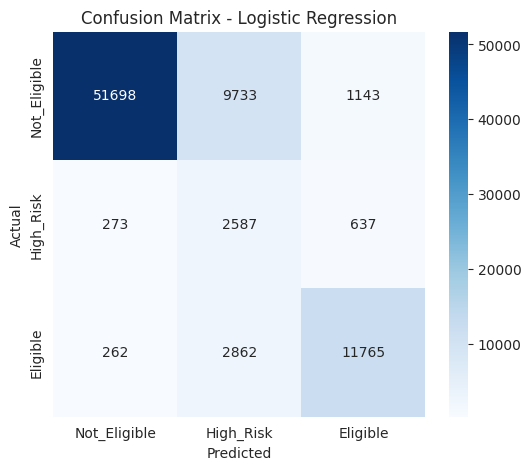

              precision    recall  f1-score   support

    Eligible       0.87      0.79      0.83     14889
   High_Risk       0.17      0.74      0.28      3497
Not_Eligible       0.99      0.83      0.90     62574

    accuracy                           0.82     80960
   macro avg       0.68      0.79      0.67     80960
weighted avg       0.93      0.82      0.86     80960



In [42]:
cm = confusion_matrix(y_test_clf, lr_preds, labels=['Not_Eligible','High_Risk','Eligible'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not_Eligible','High_Risk','Eligible'],
            yticklabels=['Not_Eligible','High_Risk','Eligible'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()
print(classification_report(y_test_clf, lr_preds))

In [44]:
# ML Model - 2 Implementation: Random Forest Classifier

with mlflow.start_run(run_name='RandomForestClassifier'):
    rf_clf = RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight=class_weight_dict,
        random_state=42, n_jobs=-1
    )
    rf_clf.fit(X_train_clf, y_train_clf)

    rf_preds = rf_clf.predict(X_test_clf)
    rf_proba = rf_clf.predict_proba(X_test_clf)

    metrics = evaluate_classifier(y_test_clf, rf_preds, rf_proba, 'Random Forest')
    clf_results.append(metrics)

    mlflow.log_param('model_type', 'RandomForestClassifier')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 15)
    mlflow.log_param('class_weight', 'balanced')
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.sklearn.log_model(rf_clf, 'model')

2026/08/23 11:46:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest -> Accuracy: 0.9196, Weighted F1: 0.9335, Macro F1: 0.7820, ROC-AUC: 0.9928


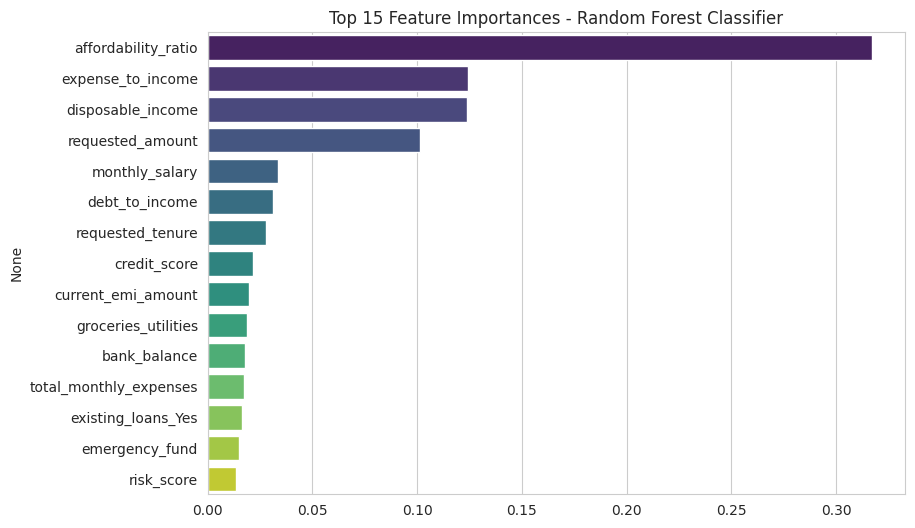

In [45]:
# Feature importance
importances = pd.Series(rf_clf.feature_importances_, index=X_train_clf.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest Classifier')
plt.show()

In [46]:
# ML Model - 3 Implementation: XGBoost Classifier

# XGBoost needs integer-encoded labels, not string labels
label_encoder = LabelEncoder()
y_train_clf_enc = label_encoder.fit_transform(y_train_clf)
y_test_clf_enc = label_encoder.transform(y_test_clf)

# Compute per-sample weights for XGBoost (it doesn't take a class_weight dict directly)
sample_weights = y_train_clf.map(class_weight_dict).values

with mlflow.start_run(run_name='XGBoostClassifier'):
    xgb_clf = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=3,
        random_state=42, n_jobs=-1, eval_metric='mlogloss'
    )
    xgb_clf.fit(X_train_clf, y_train_clf_enc, sample_weight=sample_weights)

    xgb_preds_enc = xgb_clf.predict(X_test_clf)
    xgb_proba = xgb_clf.predict_proba(X_test_clf)
    xgb_preds = label_encoder.inverse_transform(xgb_preds_enc)

    metrics = evaluate_classifier(y_test_clf, xgb_preds, xgb_proba, 'XGBoost')
    clf_results.append(metrics)

    mlflow.log_param('model_type', 'XGBoostClassifier')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.xgboost.log_model(xgb_clf, 'model')

2026/08/23 11:47:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost -> Accuracy: 0.9411, Weighted F1: 0.9510, Macro F1: 0.8364, ROC-AUC: 0.9979


                     Accuracy  Precision    Recall  Weighted_F1  Macro_F1  \
Model                                                                       
Logistic Regression  0.815835   0.932082  0.815835     0.860232  0.668378   
Random Forest        0.919627   0.956793  0.919627     0.933461  0.782028   
Random Forest        0.919627   0.956793  0.919627     0.933461  0.782028   
XGBoost              0.941057   0.970996  0.941057     0.950978  0.836410   

                      ROC_AUC  
Model                          
Logistic Regression  0.970572  
Random Forest        0.992778  
Random Forest        0.992778  
XGBoost              0.997921  


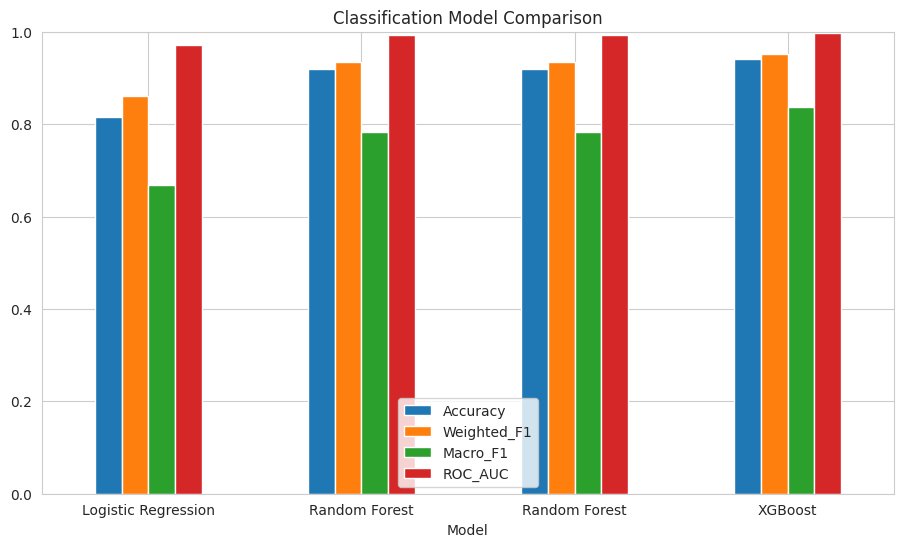

In [47]:
clf_results_df = pd.DataFrame(clf_results).set_index('Model')
print(clf_results_df)

clf_results_df[['Accuracy','Weighted_F1','Macro_F1','ROC_AUC']].plot(kind='bar', figsize=(11,6))
plt.title('Classification Model Comparison')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

In [48]:
mlflow.set_experiment('EMIPredict_Regression')

def evaluate_regressor(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}, MAPE: {mape:.2f}%")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

reg_results = []

2026/08/23 11:47:39 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_Regression' does not exist. Creating a new experiment.


In [49]:
# ML Model - 1 Implementation: Linear Regression

with mlflow.start_run(run_name='LinearRegression'):
    lr_reg = LinearRegression()
    lr_reg.fit(X_train_reg, y_train_reg)
    lr_reg_preds = lr_reg.predict(X_test_reg)

    metrics = evaluate_regressor(y_test_reg, lr_reg_preds, 'Linear Regression')
    reg_results.append(metrics)

    mlflow.log_param('model_type', 'LinearRegression')
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.sklearn.log_model(lr_reg, 'model')

2026/08/23 11:47:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression -> RMSE: 4086.47, MAE: 2942.08, R2: 0.7171, MAPE: 193.53%


In [50]:
# ML Model - 2 Implementation: Random Forest Regressor

with mlflow.start_run(run_name='RandomForestRegressor'):
    rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train_reg, y_train_reg)
    rf_reg_preds = rf_reg.predict(X_test_reg)

    metrics = evaluate_regressor(y_test_reg, rf_reg_preds, 'Random Forest')
    reg_results.append(metrics)

    mlflow.log_param('model_type', 'RandomForestRegressor')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 15)
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.sklearn.log_model(rf_reg, 'model')

2026/08/23 11:55:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest -> RMSE: 920.21, MAE: 328.15, R2: 0.9857, MAPE: 6.20%


In [51]:
# ML Model - 3 Implementation: XGBoost Regressor

with mlflow.start_run(run_name='XGBoostRegressor'):
    xgb_reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_reg.fit(X_train_reg, y_train_reg)
    xgb_reg_preds = xgb_reg.predict(X_test_reg)

    metrics = evaluate_regressor(y_test_reg, xgb_reg_preds, 'XGBoost')
    reg_results.append(metrics)

    mlflow.log_param('model_type', 'XGBoostRegressor')
    mlflow.log_param('n_estimators', 300)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    for k, v in metrics.items():
        if k != 'Model':
            mlflow.log_metric(k, v)
    mlflow.xgboost.log_model(xgb_reg, 'model')

2026/08/23 11:55:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost -> RMSE: 663.59, MAE: 262.47, R2: 0.9925, MAPE: 7.88%


                          RMSE          MAE        R2        MAPE
Model                                                            
Linear Regression  4086.472795  2942.080021  0.717136  193.528237
Random Forest       920.214264   328.148513  0.985656    6.200368
XGBoost             663.591723   262.468242  0.992541    7.883491


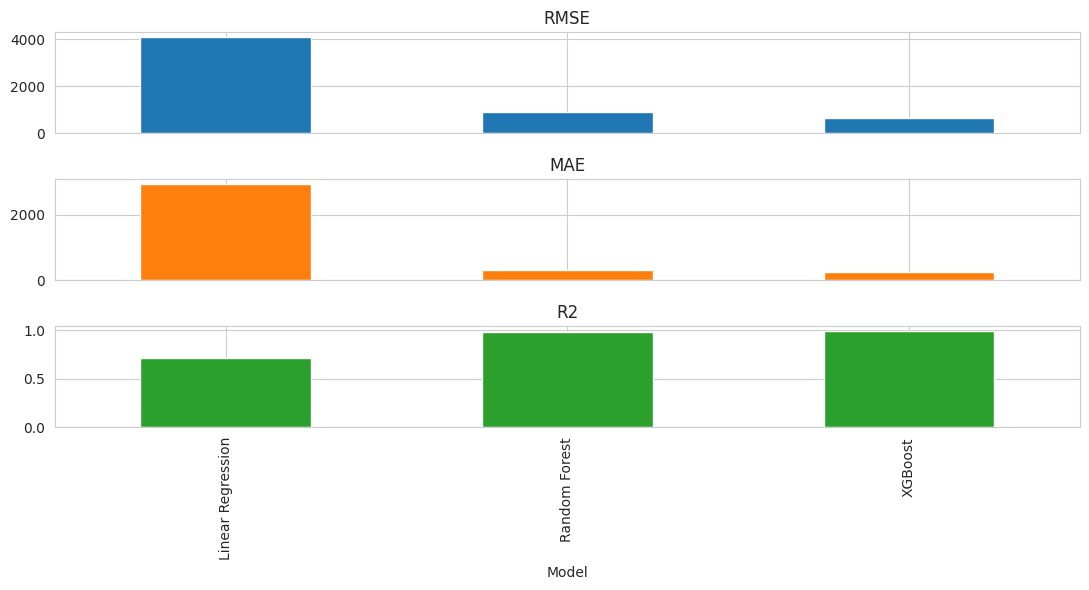

In [52]:
reg_results_df = pd.DataFrame(reg_results).set_index('Model')
print(reg_results_df)

reg_results_df[['RMSE','MAE','R2']].plot(kind='bar', figsize=(11,6), subplots=True, legend=False)
plt.tight_layout()
plt.show()

In [53]:
# View all logged runs across both experiments
all_runs = mlflow.search_runs(experiment_names=['EMIPredict_Classification', 'EMIPredict_Regression'])
all_runs[['run_id', 'tags.mlflow.runName', 'start_time'] + [c for c in all_runs.columns if c.startswith('metrics.')]]

,run_id,tags.mlflow.runName,start_time,metrics.MAE,metrics.MAPE,metrics.RMSE,metrics.R2,metrics.Macro_F1,metrics.Accuracy,metrics.Weighted_F1,metrics.ROC_AUC,metrics.Recall,metrics.Precision
0,30284cd0063d428a89128b9b1d819881,XGBoostRegressor,2026-08-23 11:55:46.179000+00:00,262.468242,7.883491,663.591723,0.992541,NaN,NaN,NaN,NaN,NaN,NaN
1,e571d82131ff41329680c772baa8ca4a,RandomForestRegressor,2026-08-23 11:48:09.700000+00:00,328.148513,6.200368,920.214264,0.985656,NaN,NaN,NaN,NaN,NaN,NaN
2,1b44fe5be75e4217b1f194d4e1952308,LinearRegression,2026-08-23 11:47:55.649000+00:00,2942.080021,193.528237,4086.472795,0.717136,NaN,NaN,NaN,NaN,NaN,NaN
3,2883ee10b6ef433583a8e9b29f2bfeb9,XGBoostClassifier,2026-08-23 11:46:41.720000+00:00,NaN,NaN,NaN,NaN,0.836410,0.941057,0.950978,0.997921,0.941057,0.970996
4,54463acd9675447891acc6404d45ffc8,RandomForestClassifier,2026-08-23 11:44:54.699000+00:00,NaN,NaN,NaN,NaN,0.782028,0.919627,0.933461,0.992778,0.919627,0.956793
5,ac6fadb4940648d6a11328526e1b41ff,RandomForestClassifier,2026-08-23 11:43:38.539000+00:00,NaN,NaN,NaN,NaN,0.782028,0.919627,0.933461,0.992778,0.919627,0.956793
6,91a4904ff2d042ae89e5ea63cbd2bb9f,LogisticRegression,2026-08-23 11:42:44.615000+00:00,NaN,NaN,NaN,NaN,0.668378,0.815835,0.860232,0.970572,0.815835,0.932082


In [57]:
best_clf_run_id = "2883ee10b6ef433583a8e9b29f2bfeb9"   # XGBoostClassifier — Macro F1 0.836, Accuracy 0.941
best_reg_run_id = "30284cd0063d428a89128b9b1d819881"    # XGBoostRegressor — RMSE 663.59, R² 0.993

mlflow.register_model(f"runs:/{best_clf_run_id}/model", "EMIPredict_Classifier")
mlflow.register_model(f"runs:/{best_reg_run_id}/model", "EMIPredict_Regressor")

Successfully registered model 'EMIPredict_Classifier'.
2026/08/23 11:59:13 WARNING mlflow.tracking._model_registry.fluent: Run with id 2883ee10b6ef433583a8e9b29f2bfeb9 has no artifacts at artifact path 'model', registering model based on models:/m-5b0e3cddd1fd4fdabd77e265647ba631 instead
Created version '1' of model 'EMIPredict_Classifier'.
Successfully registered model 'EMIPredict_Regressor'.
2026/08/23 11:59:13 WARNING mlflow.tracking._model_registry.fluent: Run with id 30284cd0063d428a89128b9b1d819881 has no artifacts at artifact path 'model', registering model based on models:/m-886335f05586490e8347aa84dc32a790 instead
Created version '1' of model 'EMIPredict_Regressor'.


<ModelVersion: aliases=[], creation_timestamp=1787486353625, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1787486353625, metrics=None, model_id=None, name='EMIPredict_Regressor', params=None, run_id='30284cd0063d428a89128b9b1d819881', run_link=None, source='models:/m-886335f05586490e8347aa84dc32a790', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

In [58]:
import joblib

# Save whichever models were selected as best above (update variable names to match your actual winners)
joblib.dump(xgb_clf, 'emi_eligibility_model.joblib')
joblib.dump(xgb_reg, 'max_emi_model.joblib')
joblib.dump(scaler, 'emi_feature_scaler.joblib')
joblib.dump(label_encoder, 'emi_eligibility_label_encoder.joblib')
joblib.dump(feature_cols, 'emi_feature_columns.joblib')
print("Models, scaler, encoder, and feature column list saved for the Streamlit app.")

Models, scaler, encoder, and feature column list saved for the Streamlit app.
